# Diabetes Data -----------------------

In [ ]:
!pip install pygam

# Generalized Linear Model (GLM)

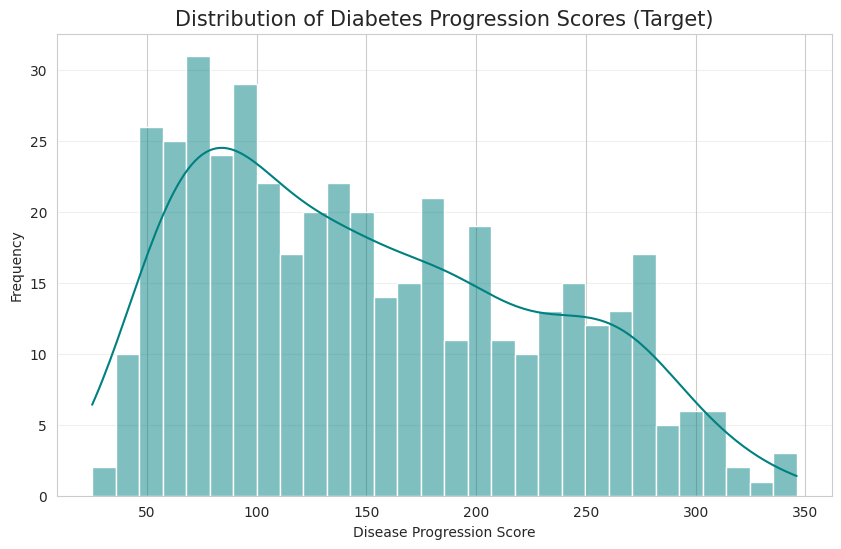

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

# 1. Load the dataset
diabetes = load_diabetes()
X_diabetes = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y_diabetes = pd.Series(diabetes.target, name="Target")

# 2. Plot the distribution of the target variable
plt.figure(figsize=(10, 6))
sns.histplot(y_diabetes, kde=True, color='teal', bins=30)
plt.title('Distribution of Diabetes Progression Scores (Target)', fontsize=15)
plt.xlabel('Disease Progression Score')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

The histogram shows that the target data is positive and slightly right-skewed (it has a tail extending to the right). It doesn't look perfectly bell-shaped (Gaussian). Since the values are continuous and positive, the Gamma distribution is a great choice here. The user's guess to use a Log link function is also standard for Gamma models, as it ensures predictions remain positive.

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
/tmp/ipykernel_965/3710679015.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefficients_diabetes.index, y=coefficients_diabetes.values, palette=colors)


                 Generalized Linear Model Regression Results                  
Dep. Variable:                 Target   No. Observations:                  353
Model:                            GLM   Df Residuals:                      342
Model Family:                   Gamma   Df Model:                           10
Link Function:                    log   Scale:                         0.14434
Method:                          IRLS   Log-Likelihood:                -1896.5
Date:                Wed, 25 Mar 2026   Deviance:                       52.945
Time:                        03:26:12   Pearson chi2:                     49.4
No. Iterations:                    13   Pseudo R-squ. (CS):             0.6225
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.9498      0.020    244.305      0.0

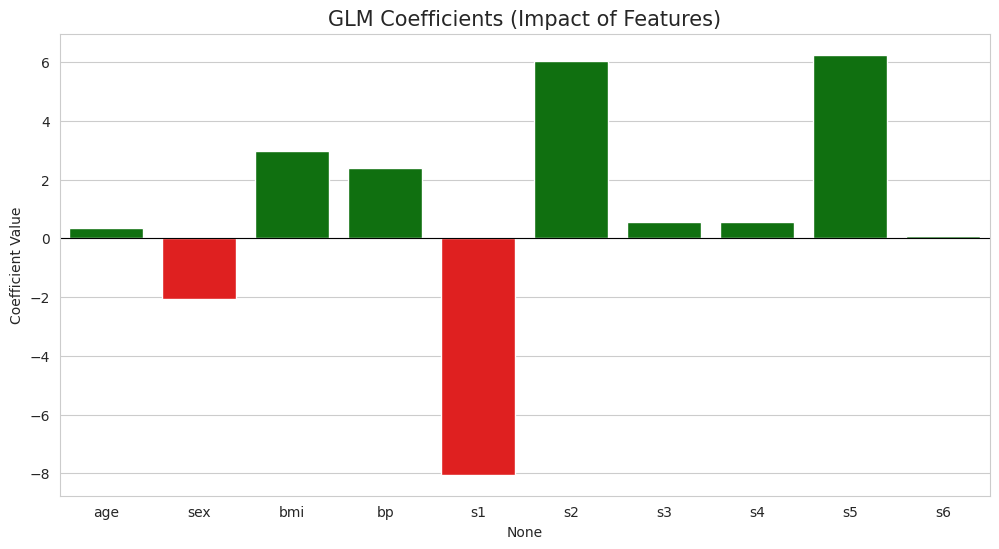

In [ ]:
# 3. Split the data
X_train_diabetes, X_test_diabetes, y_train_diabetes, y_test_diabetes = train_test_split(X_diabetes, y_diabetes, test_size=0.2, random_state=42)

# 4. Fit the GLM model
# We add a constant (intercept) because statsmodels doesn't add it by default
X_train_const_diabetes = sm.add_constant(X_train_diabetes)
X_test_const_diabetes = sm.add_constant(X_test_diabetes)

# Using Gamma family with Log link as suggested
glm_model_diabetes = sm.GLM(y_train_diabetes, X_train_const_diabetes, family=sm.families.Gamma(link=sm.families.links.log()))
glm_results_diabetes = glm_model_diabetes.fit()

# 5. Display Coefficients
print(glm_results_diabetes.summary())

# 6. Plot Coefficient Barplot
coefficients_diabetes = glm_results_diabetes.params.drop('const') # Exclude intercept for clearer plot
plt.figure(figsize=(12, 6))
colors = ['red' if x < 0 else 'green' for x in coefficients_diabetes.values]
sns.barplot(x=coefficients_diabetes.index, y=coefficients_diabetes.values, palette=colors)
plt.title('GLM Coefficients (Impact of Features)', fontsize=15)
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('Coefficient Value')
plt.show()

The bar plot helps us visualize "importance."

Green bars (positive coefficients) mean that as this feature increases, the disease progression score likely increases. You might see high positive bars for features like bmi (Body Mass Index) or s5.

Red bars (negative coefficients) mean that increasing this feature lowers the score.

Note: Since we used a Log link, these coefficients represent a multiplicative effect on the target, not a simple additive one.

# Generalized Additive Model (GAM)

In [ ]:
# !pip install pygam
from pygam import LinearGAM, s, l
from sklearn.metrics import mean_squared_error, r2_score

# 1. Setup the GAM
# We use s() for spline terms. Since we have 10 features, we create a term for each.
# 'n_splines' controls how "wiggly" the line can be.
# We will treat all features as continuous splines for simplicity here.
gam_diabetes = LinearGAM(s(0) + s(1) + s(2) + s(3) + s(4) + s(5) + s(6) + s(7) + s(8) + s(9))

# 2. Gridsearch to find the best smoothing parameters (lambdas)
print("Searching for optimal parameters...")
gam_diabetes.gridsearch(X_train_diabetes.values, y_train_diabetes.values)

# 3. Fit is done automatically by gridsearch, so we can predict now
y_pred_diabetes = gam_diabetes.predict(X_test_diabetes)

# 4. Calculate Metrics
mse_diabetes = mean_squared_error(y_test_diabetes, y_pred_diabetes)
r2_diabetes = r2_score(y_test_diabetes, y_pred_diabetes)

print(f"\nModel Performance:")
print(f"Mean Squared Error (MSE): {mse_diabetes:.2f}")
print(f"R-Squared: {r2_diabetes:.2f}")

# 5. GAM Summary
gam_diabetes.summary()

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--

Searching for optimal parameters...


100% (11 of 11) |########################| Elapsed Time: 0:00:02 Time:  0:00:02



Model Performance:
Mean Squared Error (MSE): 2750.61
R-Squared: 0.48
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     17.7204
Link Function:                     IdentityLink Log Likelihood:                                 -1897.8353
Number of Samples:                          353 AIC:                                             3833.1114
                                                AICc:                                            3835.3268
                                                GCV:                                             3162.6608
                                                Scale:                                             53.6491
                                                Pseudo R-Squared:         

/tmp/ipykernel_965/2853840562.py:27: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam_diabetes.summary()


The gridsearch function tries different "smoothing" values to prevent overfitting.

Check the R-Squared value. If it is higher than a simple linear regression model, it means the "curved" relationships captured by GAM describe the data better than straight lines.

The summary table shows EDoF (Effective Degrees of Freedom). A value close to 1 means the relationship is linear. A higher value (like 4 or 5) means the feature has a complex, non-linear relationship with diabetes progression.

# PDP - Partial Dependency Plots

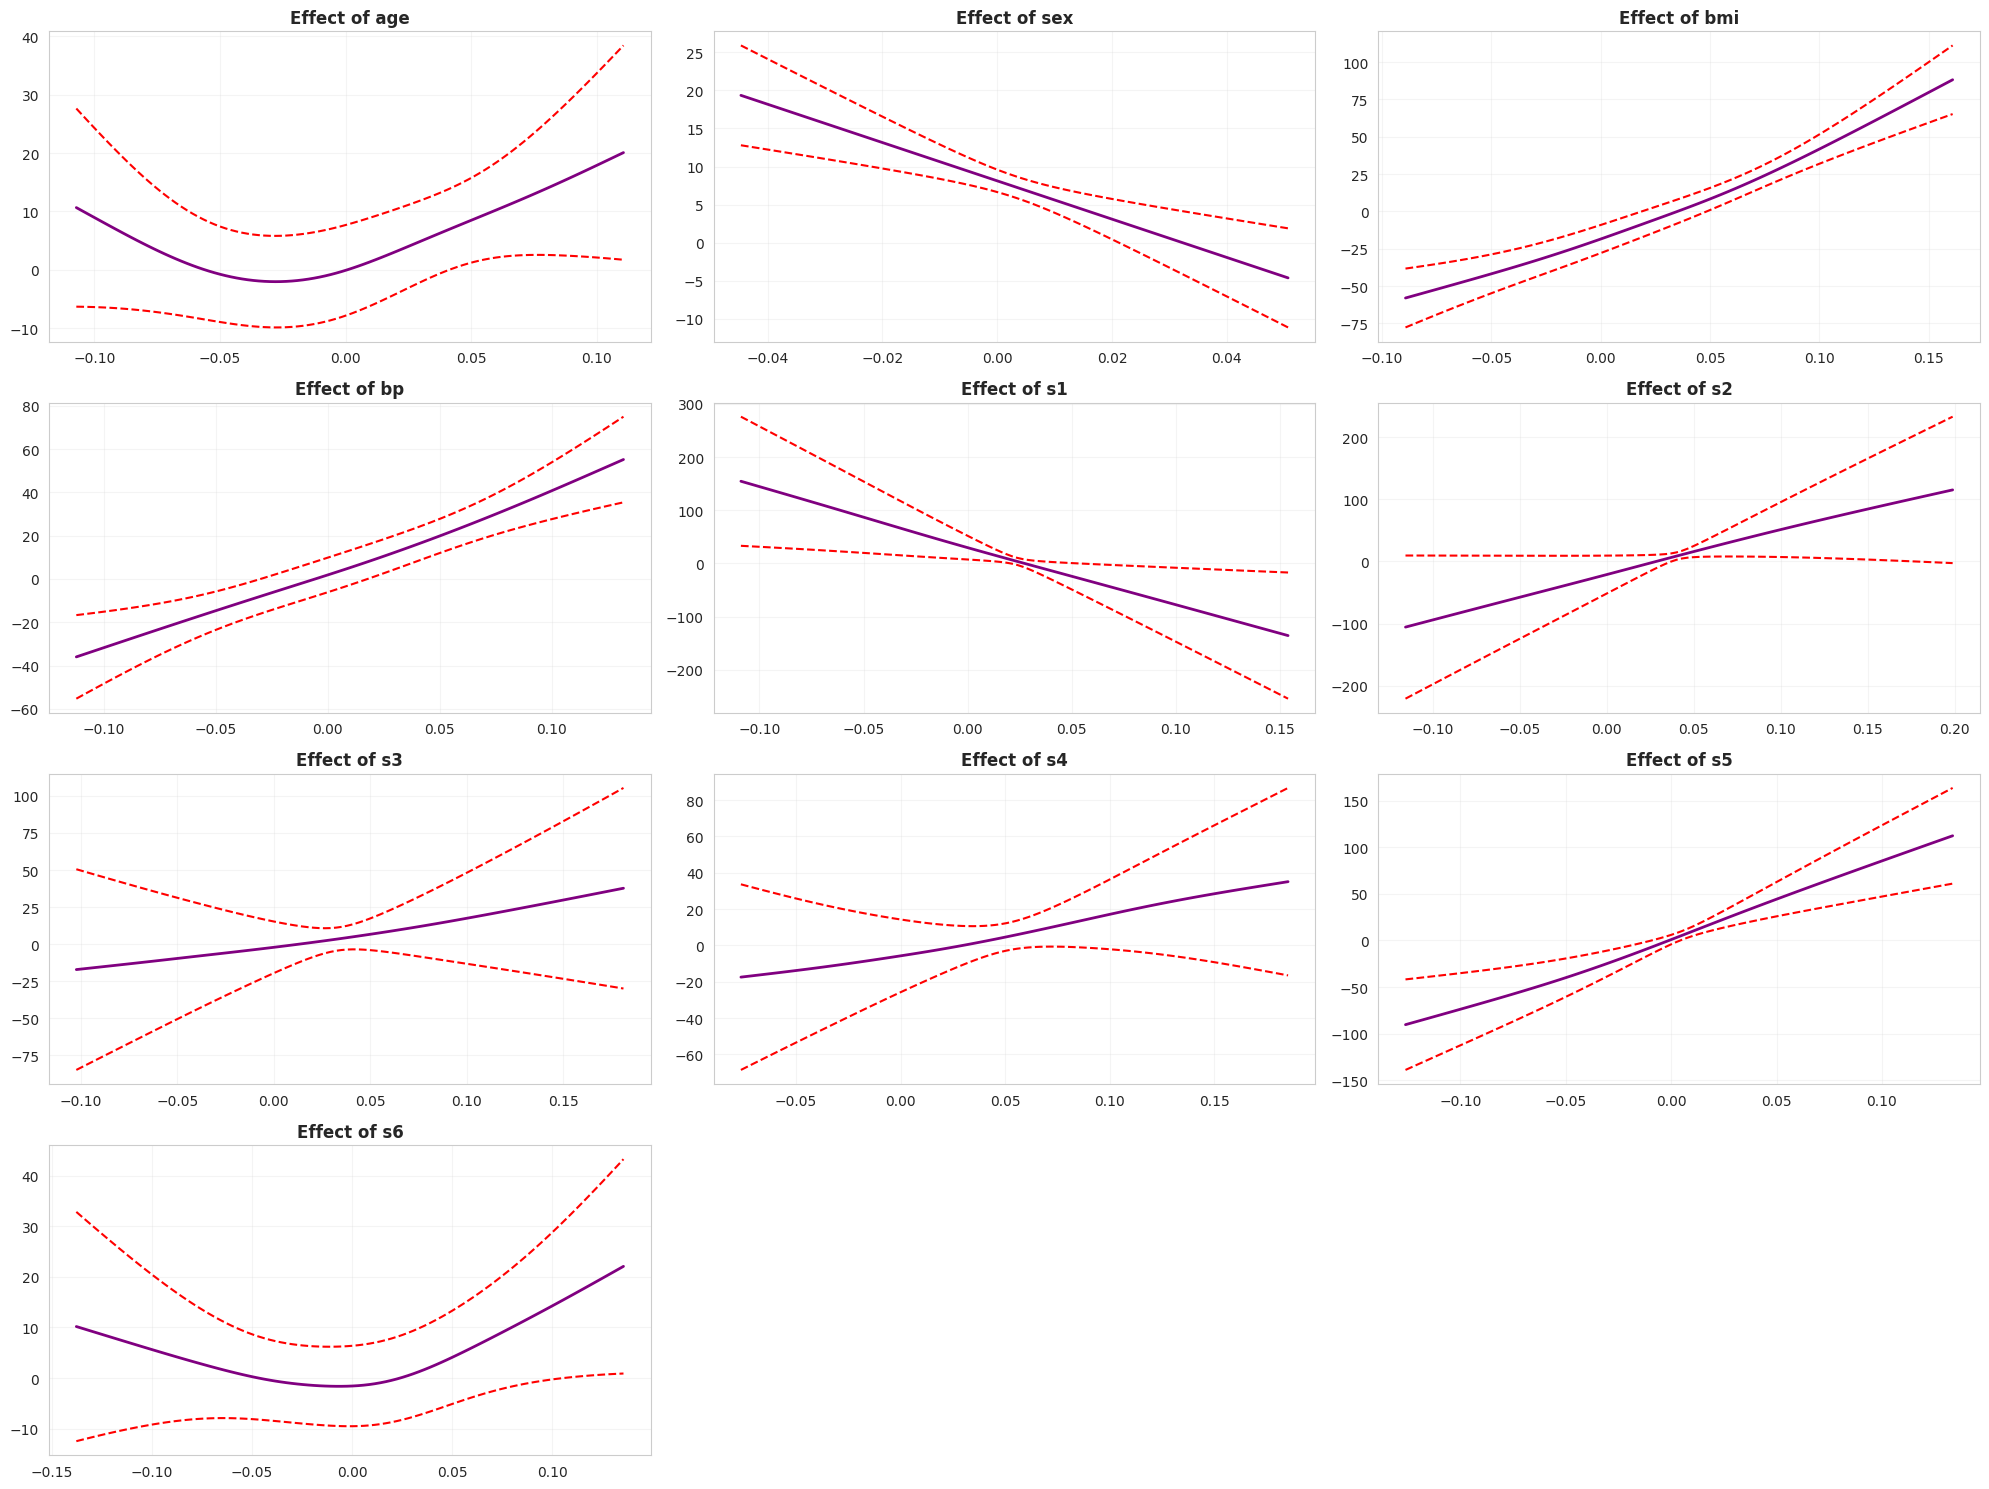

In [ ]:
# Plotting setup
plt.figure(figsize=(20, 15))
titles = diabetes.feature_names

# Loop through all 10 features
for i, feature in enumerate(titles):
    plt.subplot(4, 3, i + 1) # Arrange plots in a grid

    # Generate the partial dependence data
    XX = gam_diabetes.generate_X_grid(term=i)

    # Plot the line (prediction) and the confidence intervals (error bars)
    plt.plot(XX[:, i], gam_diabetes.partial_dependence(term=i, X=XX), color='purple', linewidth=2)
    plt.plot(XX[:, i], gam_diabetes.partial_dependence(term=i, X=XX, width=.95)[1], c='r', ls='--')

    plt.title(f'Effect of {feature}', fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

Curvature: Look at the plot for bmi or s5. If the line curves significantly (e.g., flattens out or rises sharply), it proves that a simple linear model would have missed this pattern.

Confidence Intervals (Dotted Red Lines): These show our uncertainty. Where the red lines are far apart, we have less data, so the model is less sure about the prediction in that region.

Flat Lines: If a line is mostly flat (horizontal), that feature doesn't have much impact on the diabetes score in this model.

# Breast Cancer Dataset --------------------

# Generalized Linear Model (GLM)

/tmp/ipykernel_965/3885561823.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_cancer, palette=['#FF9999', '#66B2FF'])


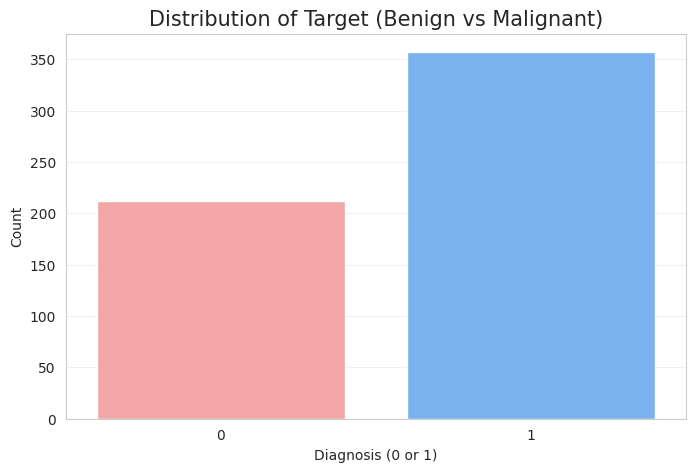

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

# 1. Load the dataset
data_cancer = load_breast_cancer()
# We will use only the first 10 features to keep the plots simple and readable
X_cancer = pd.DataFrame(data_cancer.data, columns=data_cancer.feature_names).iloc[:, :10]
y_cancer = pd.Series(data_cancer.target, name="Target (0=Malignant, 1=Benign)")

# 2. Plot the distribution of the target variable
plt.figure(figsize=(8, 5))
sns.countplot(x=y_cancer, palette=['#FF9999', '#66B2FF'])
plt.title('Distribution of Target (Benign vs Malignant)', fontsize=15)
plt.xlabel('Diagnosis (0 or 1)')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.show()

Unlike the Diabetes data (which was a curve), this is a Binary Distribution (only two bars). This tells us we cannot use a normal Linear Regression. We must use a model designed for "Yes/No" questions.

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The logit link alias is deprecated. Use Logit instead. The logit link alias will be removed after the 0.15.0 release.
  warnings.warn(
/tmp/ipykernel_965/453717269.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefficients_cancer.index, y=coefficients_cancer.values, palette=colors)


                       Generalized Linear Model Regression Results                        
Dep. Variable:     Target (0=Malignant, 1=Benign)   No. Observations:                  455
Model:                                        GLM   Df Residuals:                      444
Model Family:                            Binomial   Df Model:                           10
Link Function:                              logit   Scale:                          1.0000
Method:                                      IRLS   Log-Likelihood:                -60.673
Date:                            Wed, 25 Mar 2026   Deviance:                       121.35
Time:                                    03:26:17   Pearson chi2:                     182.
No. Iterations:                                 9   Pseudo R-squ. (CS):             0.6510
Covariance Type:                        nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]

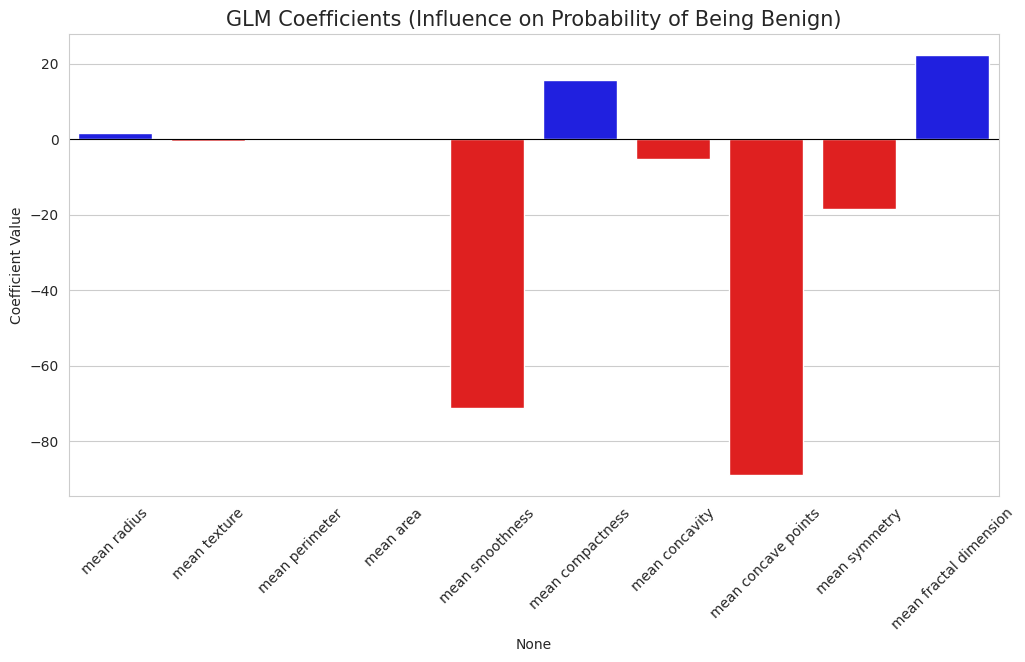

In [ ]:
# 3. Split the data
X_train_cancer, X_test_cancer, y_train_cancer, y_test_cancer = train_test_split(X_cancer, y_cancer, test_size=0.2, random_state=42)

# 4. Fit the GLM model
# We use Binomial Family because the target is 0 or 1
X_train_const_cancer = sm.add_constant(X_train_cancer)
glm_model_cancer = sm.GLM(y_train_cancer, X_train_const_cancer, family=sm.families.Binomial(link=sm.families.links.logit()))
glm_results_cancer = glm_model_cancer.fit()

# 5. Display Coefficients
print(glm_results_cancer.summary())

# 6. Plot Coefficient Barplot
coefficients_cancer = glm_results_cancer.params.drop('const')
plt.figure(figsize=(12, 6))
colors = ['red' if x < 0 else 'blue' for x in coefficients_cancer.values]
sns.barplot(x=coefficients_cancer.index, y=coefficients_cancer.values, palette=colors)
plt.title('GLM Coefficients (Influence on Probability of Being Benign)', fontsize=15)
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45)
plt.ylabel('Coefficient Value')
plt.show()

Blue bars (Positive): Features that make it more likely to be Benign (Safe).

Red bars (Negative): Features that make it more likely to be Malignant (Cancerous).

Because we used the Logit link, these coefficients are measuring "Log Odds." A large negative bar means that as that feature (like "mean radius") gets larger, the chance of the tumor being safe drops drastically.

# Generalized Additive Model (GAM)

In [ ]:
# !pip install pygam
from pygam import LogisticGAM, s
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. Setup the GAM
# We use s() for splines. We are using the 10 features we selected earlier.
gam_cancer = LogisticGAM(s(0) + s(1) + s(2) + s(3) + s(4) + s(5) + s(6) + s(7) + s(8) + s(9))

# 2. Gridsearch to find optimal smoothing
print("Searching for optimal parameters...")
gam_cancer.gridsearch(X_train_cancer.values, y_train_cancer.values)

# 3. Predict
# For classification, gam_cancer.predict() gives strictly 0 or 1
y_pred_cancer = gam_cancer.predict(X_test_cancer)

# 4. Calculate Metrics
acc_cancer = accuracy_score(y_test_cancer, y_pred_cancer)
cm_cancer = confusion_matrix(y_test_cancer, y_pred_cancer)

print(f"\nModel Performance:")
print(f"Accuracy: {acc_cancer*100:.2f}%")
print("Confusion Matrix:\n", cm_cancer)

# 5. GAM Summary
gam_cancer.summary()

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--

Searching for optimal parameters...


/usr/local/lib/python3.12/dist-packages/pygam/links.py:137: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/usr/local/lib/python3.12/dist-packages/pygam/pygam.py:631: RuntimeWarning: invalid value encountered in multiply
  self.link.gradient(mu, self.distribution) ** 2
/usr/local/lib/python3.12/dist-packages/pygam/pygam.py:631: RuntimeWarning: overflow encountered in square
  self.link.gradient(mu, self.distribution) ** 2
  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:08/usr/local/lib/python3.12/dist-packages/pygam/links.py:137: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/usr/local/lib/python3.12/dist-packages/pygam/pygam.py:631: RuntimeWarning: overflow encountered in square
  self.link.gradient(mu, self.distribution) ** 2
/usr/local/lib/python3.12/dist-packages/pygam/pygam.py:631: RuntimeWarning: invalid value encountered in multiply
  self.l


Model Performance:
Accuracy: 96.49%
Confusion Matrix:
 [[41  2]
 [ 2 69]]
LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                     16.7264
Link Function:                        LogitLink Log Likelihood:                                   -44.6011
Number of Samples:                          455 AIC:                                              122.6549
                                                AICc:                                             124.1767
                                                UBRE:                                                2.299
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:    

/tmp/ipykernel_965/586568369.py:26: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam_cancer.summary()


Accuracy: This tells you what percentage of patients were correctly diagnosed by the model.

Effective Degrees of Freedom (EDoF): In the summary, look at EDoF. If a feature has a value much higher than 1 (e.g., 5 or 6), it means the risk of cancer doesn't just go up or down in a straight line—it likely has a complex "tipping point."

# PDP - Partial Dependency Plots

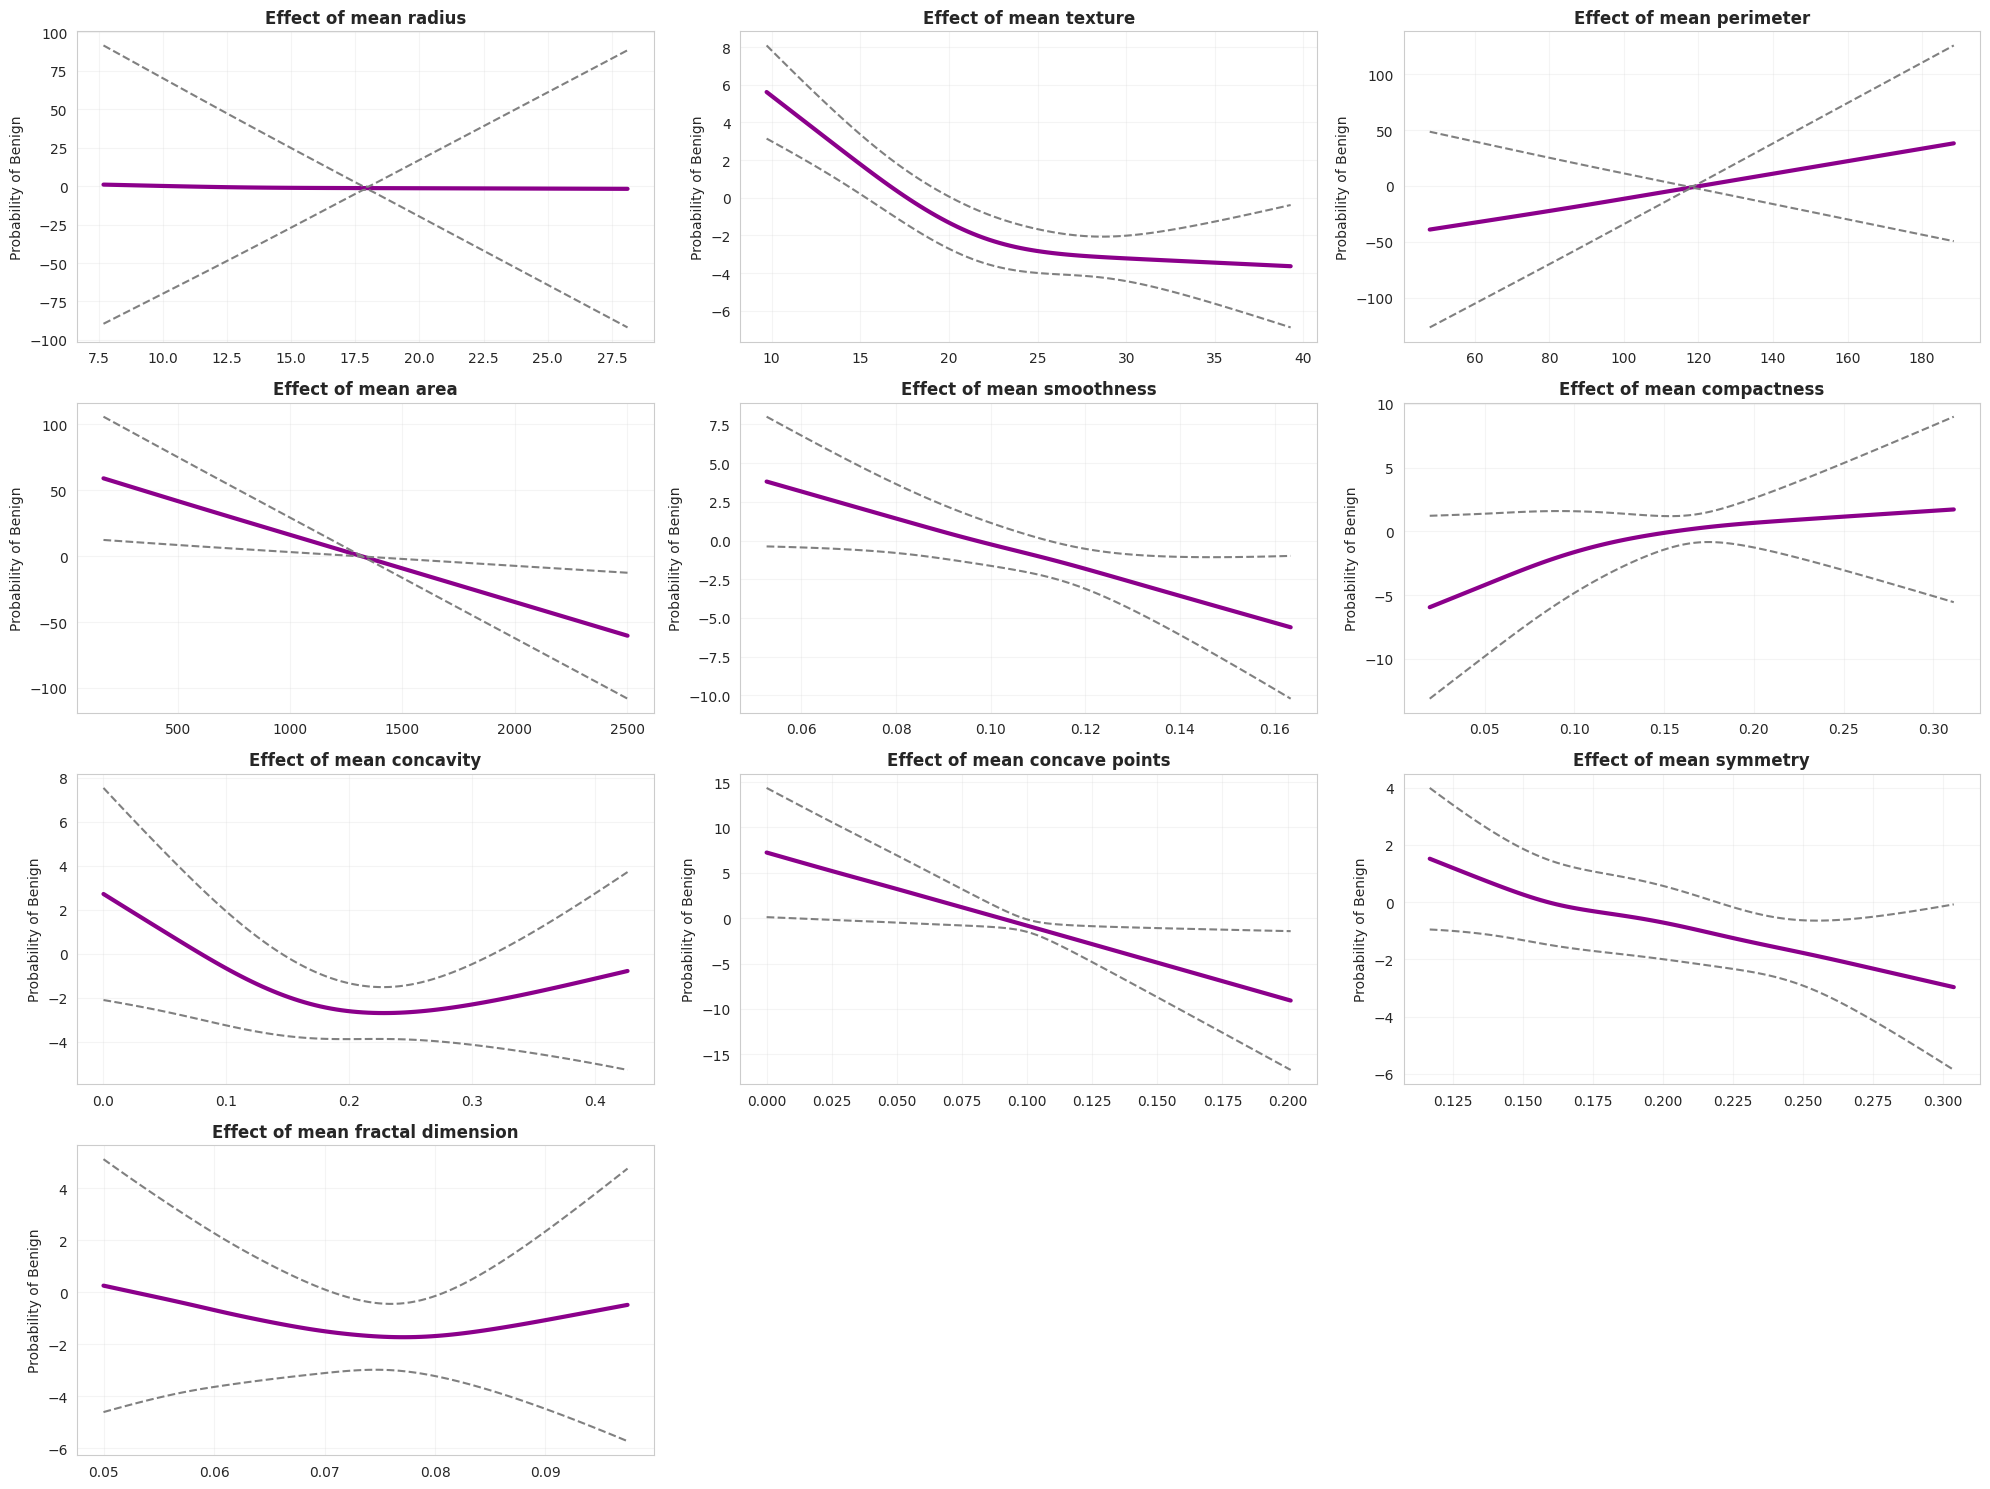

In [ ]:
# Plotting setup
plt.figure(figsize=(20, 15))
titles = X_cancer.columns # Using the column names from our dataframe

for i, feature in enumerate(titles):
    plt.subplot(4, 3, i + 1)

    # Generate grid
    XX = gam_cancer.generate_X_grid(term=i)

    # Plot the probability line (0 to 1)
    # Note: We use predict_proba to get the probability curve, not just 0/1
    plt.plot(XX[:, i], gam_cancer.partial_dependence(term=i, X=XX), color='darkmagenta', linewidth=3)
    plt.plot(XX[:, i], gam_cancer.partial_dependence(term=i, X=XX, width=.95)[1], c='gray', ls='--')

    plt.title(f'Effect of {feature}', fontsize=12, fontweight='bold')
    plt.ylabel('Probability of Benign')
    plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
!pip install shap

  0%|          | 0/20 [00:00<?, ?it/s]

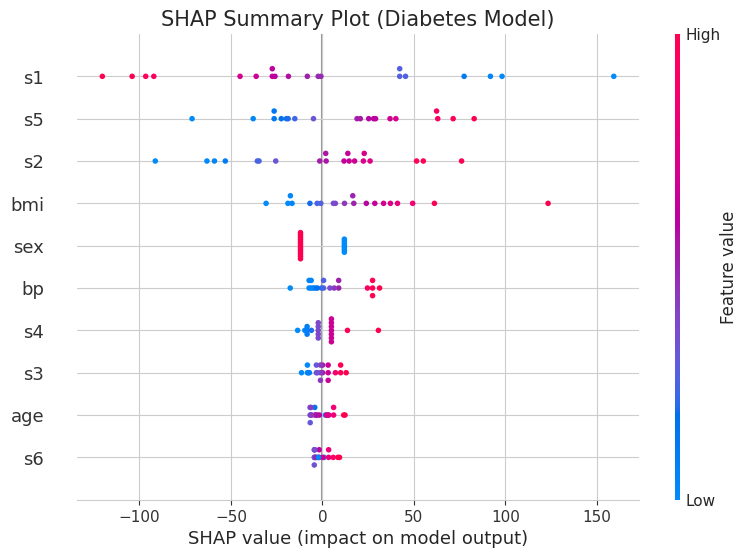

Explanation for a single patient prediction:


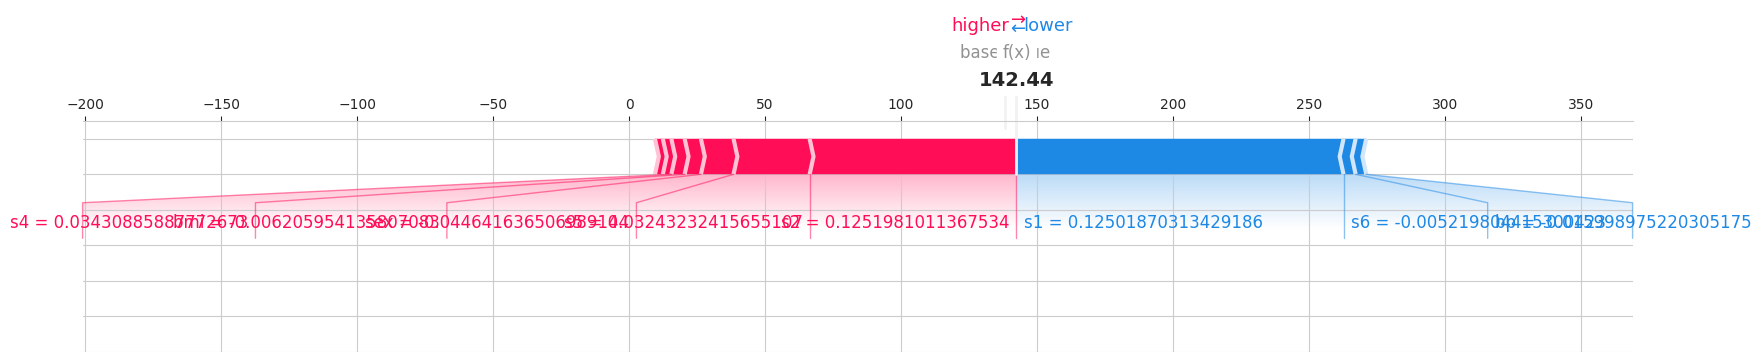

In [ ]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize the SHAP Explainer
# LinearGAM isn't natively supported by TreeExplainer, so we use KernelExplainer or Explainer
# For simplicity and speed with this model, we'll use a KernelExplainer on a sample
explainer = shap.KernelExplainer(gam_diabetes.predict, shap.sample(X_train_diabetes, 10))

# 2. Calculate SHAP values for a subset of the test data
shap_values = explainer.shap_values(X_test_diabetes.iloc[:20, :])

# 3. Summary Plot (Overall feature importance)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_diabetes.iloc[:20, :], show=False)
plt.title('SHAP Summary Plot (Diabetes Model)', fontsize=15)
plt.show()

# 4. Force Plot for a single prediction
print("Explanation for a single patient prediction:")
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0, :], X_test_diabetes.iloc[0, :], matplotlib=True)

ADD---

ice plots centered ice
iris random forest explanation using lime
saliency map

# Individual Conditional Expectation (ICE) Plots

ICE plots refine Partial Dependence Plots by showing the functional relationship between the predicted response and a feature for *each* individual observation. Centered ICE plots anchor these curves to zero at the minimum feature value to highlight the variance in the slopes.

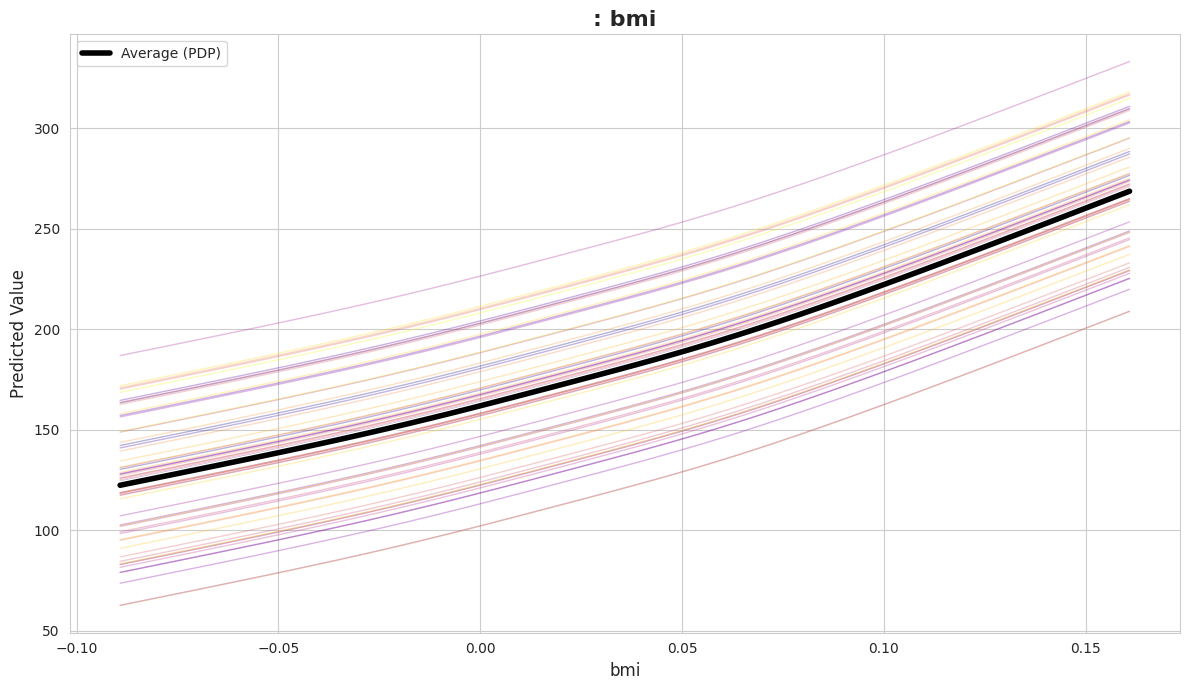

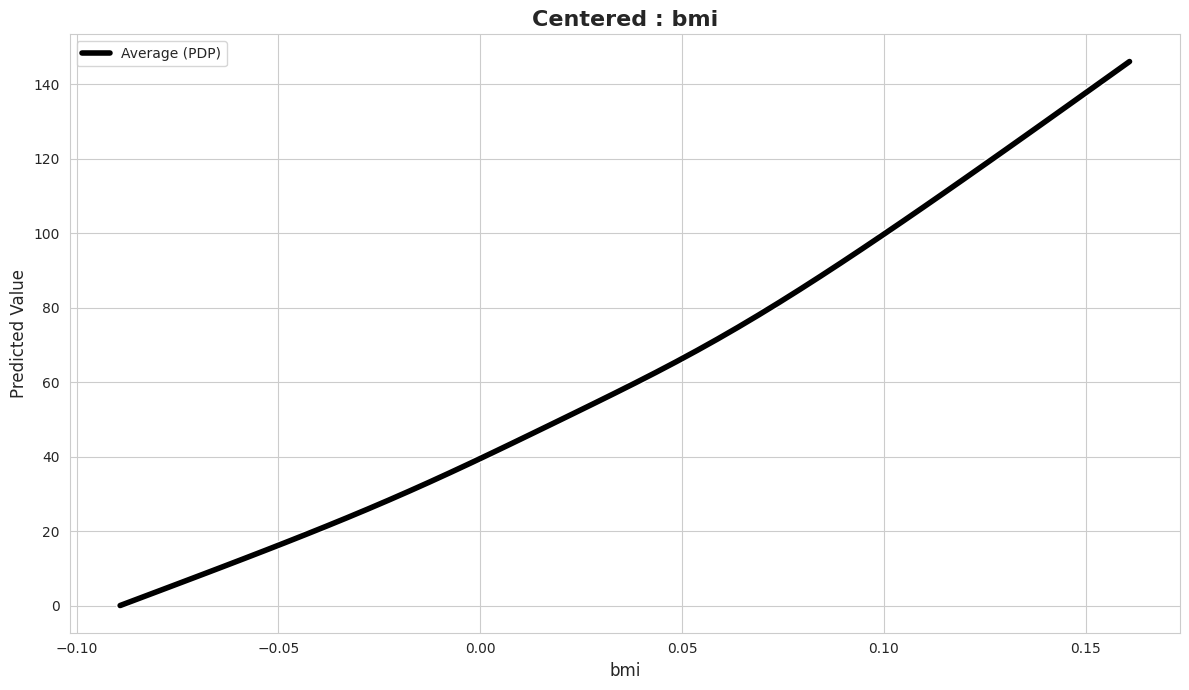

In [ ]:
!pip install pygam
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as patheffects
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from pygam import LinearGAM, s

# 1. Re-initialize data and model if not present
try:
    _ = gam_diabetes, X_train_diabetes
except NameError:
    print("Initializing Diabetes model and data...")
    diabetes = load_diabetes()
    X_diabetes = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
    y_diabetes = pd.Series(diabetes.target)
    X_train_diabetes, X_test_diabetes, y_train_diabetes, y_test_diabetes = train_test_split(X_diabetes, y_diabetes, test_size=0.2, random_state=42)
    gam_diabetes = LinearGAM(s(0) + s(1) + s(2) + s(3) + s(4) + s(5) + s(6) + s(7) + s(8) + s(9)).fit(X_train_diabetes, y_train_diabetes)

def plot_colorful_ice(model, X, feature_idx, feature_name, centered=False):
    grid = np.linspace(X.iloc[:, feature_idx].min(), X.iloc[:, feature_idx].max(), 50)
    X_temp = X.copy().values

    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")

    # Select a subset of rows
    num_samples = min(60, len(X_temp))
    sample_idx = np.random.choice(len(X_temp), num_samples, replace=False)

    ice_curves = []
    # Use a colorful colormap
    colors = plt.cm.plasma(np.linspace(0, 1, num_samples))

    for idx, i in enumerate(sample_idx):
        row_grid = np.tile(X_temp[i], (50, 1))
        row_grid[:, feature_idx] = grid
        preds = model.predict(row_grid)
        if centered:
            preds = preds - preds[0]
        ice_curves.append(preds)
        plt.plot(grid, preds, color=colors[idx], alpha=0.3, linewidth=1)

    # Plot the average (PDP line) in a bold contrasting color with a white stroke for visibility
    plt.plot(grid, np.mean(ice_curves, axis=0), color='black', linewidth=4, label='Average (PDP)',
             path_effects=[patheffects.withStroke(linewidth=6, foreground='white')])

    plt.title(f"{'Centered ' if centered else ''}: {feature_name}", fontsize=16, fontweight='bold')
    plt.xlabel(feature_name, fontsize=12)
    plt.ylabel('Predicted Value', fontsize=12)
    plt.legend(facecolor='white', frameon=True)
    plt.tight_layout()
    plt.show()

# Visualize colorful ICE for 'bmi'
plot_colorful_ice(gam_diabetes, X_train_diabetes, 2, 'bmi', centered=False)
plot_colorful_ice(gam_diabetes, X_train_diabetes, 2, 'bmi', centered=True)